# Quantum kernel SVC on Iris: unconstrained vs matchgate

<table class="nt-notebook-buttons" align="center">
  <td>
    <a target="_blank" href="https://MatchCake.github.io/MajoranaKaraoke/">Documentation</a>
  </td>
  <td>
    <a target="_blank" href="https://colab.research.google.com/github/MatchCake/MajoranaKaraoke/blob/main/tutorials/iris_kernel_svc.ipynb">Run in Google Colab</a>
  </td>
  <td>
    <a target="_blank" href="https://github.com/MatchCake/MajoranaKaraoke/blob/main/tutorials/iris_kernel_svc.ipynb">View source on GitHub</a>
  </td>
  <td>
    <a href="https://github.com/MatchCake/MajoranaKaraoke/blob/main/tutorials/iris_kernel_svc.ipynb?raw=true">Download notebook</a>
  </td>
</table>

In this tutorial, we build one quantum fidelity kernel from a 4-qubit embedding circuit and evaluate the **same**
circuit on two devices:

- `default.qubit`, PennyLane's state-vector simulator, which applies the circuit as written (the *unconstrained*
  kernel);
- `mk.qubit`, the MajoranaKaraoke device, which translates the circuit into matchgates and simulates the result with
  MatchCake's free-fermion device (the *matchgate* kernel).

The translation is exact only for circuits made of matchgates on neighbouring wires and diagonal single-qubit gates,
which this embedding is not, so the two devices compute different kernels. We measure how different they are, train
a support vector classifier (SVC) on the Iris dataset with each of them, and compare both with a classical RBF SVC.

## Setup

Install the package and the extra libraries used here (scikit-learn and matplotlib), for example on Google Colab, by
uncommenting the following line:

In [1]:
# @title Install dependencies {display-mode: "form"}

# !pip install git+https://github.com/MatchCake/MajoranaKaraoke scikit-learn matplotlib

## Imports

Installing `majorana_karaoke` registers the `mk.qubit` device with PennyLane, so `qml.device("mk.qubit", ...)` needs
no import. We import `MatchgateTranslator` only to inspect the translation.

In [2]:
import time
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pennylane as qml
import torch
from sklearn import datasets
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.svm import SVC

from majorana_karaoke import MatchgateTranslator

## Parameters

One qubit per Iris feature, two embedding layers, 30% of the data for testing, and a fixed seed for the split and the
cross-validation folds. `mk.qubit` computes with torch, which we limit to one thread so that its run time does not
depend on the number of cores of the machine.

In [3]:
N_QUBITS = 4
N_LAYERS = 2
TEST_SIZE = 0.3
SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)
torch.set_num_threads(1)  # mk.qubit works on small matrices, for which extra torch threads mostly add overhead

## Load and scale the data

Iris has 150 samples, 4 features and 3 classes. We keep 30% of the samples for testing with a stratified split, then
scale every feature to $[0, \pi]$ with a scaler fitted on the training set only.

In [4]:
dataset = datasets.load_iris()
x_train, x_test, y_train, y_test = train_test_split(
    dataset.data, dataset.target, test_size=TEST_SIZE, stratify=dataset.target, random_state=SEED
)
scaler = MinMaxScaler(feature_range=(0, np.pi)).fit(x_train)
x_train, x_test = scaler.transform(x_train), scaler.transform(x_test)
print(f"Train: {x_train.shape}, samples per class {np.bincount(y_train)}")
print(f"Test:  {x_test.shape}, samples per class {np.bincount(y_test)}")

Train: (105, 4), samples per class [35 35 35]
Test:  (45, 4), samples per class [15 15 15]


## Embedding circuit and fidelity kernel

The embedding $U(x)$ repeats two layers of $R_Y(x_i)$ rotations followed by a ring of CNOTs,

$$
U(x) = \prod_{l=1}^{2} \left[ \mathrm{CNOT}_{3,0}\,\mathrm{CNOT}_{2,3}\,\mathrm{CNOT}_{1,2}\,\mathrm{CNOT}_{0,1}
\bigotimes_{i=0}^{3} R_Y(x_i) \right],
$$

and the fidelity kernel is the probability of measuring $|0000\rangle$ after $U(x)$ followed by $U(x')^\dagger$:

$$
k(x, x') = \left|\langle 0000 | U(x')^\dagger U(x) | 0000 \rangle\right|^2
= \langle \psi | P_{0000} | \psi \rangle, \qquad |\psi\rangle = U(x')^\dagger U(x)|0000\rangle,
$$

with $P_{0000} = |0000\rangle\langle 0000|$. The function `make_kernel` builds this circuit as a QNode on any device,
so both devices run exactly the same PennyLane code.

In [5]:
def embedding(x, wires):
    n_wires = len(wires)
    for _ in range(N_LAYERS):
        qml.AngleEmbedding(x, wires=wires, rotation="Y")
        for index in range(n_wires):
            qml.CNOT(wires=[wires[index], wires[(index + 1) % n_wires]])


def make_kernel(device_name, n_qubits):
    wires = list(range(n_qubits))

    @qml.qnode(qml.device(device_name, wires=n_qubits))
    def kernel(x1, x2):
        embedding(x1, wires)
        qml.adjoint(embedding)(x2, wires)
        return qml.expval(qml.Projector(np.zeros(n_qubits, dtype=int), wires=wires))

    return kernel


unconstrained_kernel = make_kernel("default.qubit", N_QUBITS)
matchgate_kernel = make_kernel("mk.qubit", N_QUBITS)

print(qml.draw(qml.transforms.decompose(embedding, gate_set={"RY", "CNOT"}), decimals=2)(x_train[0], range(N_QUBITS)))

0: ──RY(2.09)─╭●───────╭X──RY(2.09)─╭●───────╭X─┤  
1: ──RY(1.70)─╰X─╭●────│───RY(1.70)─╰X─╭●────│──┤  
2: ──RY(2.50)────╰X─╭●─│───RY(2.50)────╰X─╭●─│──┤  
3: ──RY(3.14)───────╰X─╰●──RY(3.14)───────╰X─╰●─┤  


## What `mk.qubit` actually runs

Before simulating a circuit, `mk.qubit` translates every gate into matchgates with a `MatchgateTranslator`. The
translation is exact only for circuits made of matchgates on neighbouring wires and diagonal single-qubit gates, and
$U(x)$ is not such a circuit:

- $R_Y(x_i)$ is not diagonal. For $i < 3$, it is replaced by the matchgate
  $\mathrm{CNOT}_{i,i+1}\,(R_Y(x_i) \otimes I)\,\mathrm{CNOT}_{i,i+1}$ on the wires $(i, i+1)$; on the last wire,
  by $\mathrm{CNOT}_{3,2}\,(I \otimes R_Y(x_3))\,\mathrm{CNOT}_{3,2}$ on the wires $(2, 3)$.
- A CNOT is not a matchgate. It is first rewritten, exactly up to a global phase, as single-qubit rotations around the
  matchgate $\mathrm{XX}(\pi/2) = e^{-i\frac{\pi}{4} X \otimes X}$, then these rotations are dressed like $R_Y$.
- $\mathrm{CNOT}_{3,0}$ closes the ring on non-neighbouring wires. Fermionic swaps (fSWAP) move wire 3 next to wire 0
  for its $\mathrm{XX}(\pi/2)$ and back, which gives the fermionic counterpart of $\mathrm{XX}(\pi/2)$ on the wires
  $(3, 0)$, not the qubit gate itself.

The next cell prints the translation of each kind of gate of $U(x)$ and the gate counts of the whole embedding.

In [6]:
translator = MatchgateTranslator()
for op in [qml.RY(0.5, wires=0), qml.RY(0.5, wires=3), qml.CNOT(wires=[0, 1]), qml.CNOT(wires=[3, 0])]:
    translated_ops = translator.translate(op, wire_order=range(N_QUBITS))
    translated_names = ", ".join(f"{new_op.name}{new_op.wires.tolist()}" for new_op in translated_ops)
    print(f"{op.name}{op.wires.tolist()} -> {translated_names}")

embedding_tape = qml.tape.make_qscript(embedding)(x_train[0], list(range(N_QUBITS)))
decomposed_tape = qml.transforms.decompose(embedding_tape, gate_set={"RY", "CNOT"})[0][0]
translated_tape = translator.translate_tape(embedding_tape, wire_order=range(N_QUBITS))
print("\nU(x) gates:", dict(Counter(op.name for op in decomposed_tape.operations)))
print("V(x) gates:", dict(Counter(op.name for op in translated_tape.operations)))

RY[0] -> MatchgateOperation[0, 1]
RY[3] -> MatchgateOperation[2, 3]
CNOT[0, 1] -> MatchgateOperation[0, 1], MatchgateOperation[0, 1], MatchgateOperation[0, 1], MatchgateOperation[1, 2], MatchgateOperation[0, 1]
CNOT[3, 0] -> MatchgateOperation[2, 3], fSWAP[2, 3], fSWAP[1, 2], MatchgateOperation[0, 1], fSWAP[1, 2], fSWAP[2, 3], MatchgateOperation[2, 3], MatchgateOperation[0, 1], MatchgateOperation[2, 3]

U(x) gates: {'RY': 8, 'CNOT': 8}
V(x) gates: {'MatchgateOperation': 48, 'fSWAP': 8}


`mk.qubit` therefore evaluates the fidelity kernel of another circuit $V(x)$, the matchgate counterpart (the
"karaoke" version) of $U(x)$:

$$
k_{\mathrm{mg}}(x, x') = \left|\langle 0000 | V(x')^\dagger V(x) | 0000 \rangle\right|^2 .
$$

`qml.adjoint` wraps every operation of $U(x')$ in an `Adjoint` operation, in reverse order. The translator turns each
one into the inverse of the translation of its base, so together they give $V(x')^\dagger$, the inverse of the
translation of $U(x')$, and $k_{\mathrm{mg}}$ is a fidelity kernel in its own right. The sanity checks below
confirm it numerically.

## Gram matrices with parameter broadcasting

Both devices support parameter broadcasting: calling the kernel QNode with two batches `x1` and `x2` of shape
`(B, 4)` evaluates the $B$ kernel values $k(x_b, x'_b)$, $b = 1, \dots, B$, in one execution. `gram_matrix` lists
every pair of rows of `x_a` and `x_b`, evaluates them in a single call, and reshapes the result. `mk.qubit` returns
torch tensors, so we convert the result to NumPy before passing it to scikit-learn.

In [7]:
def gram_matrix(kernel, x_a, x_b):
    rows, cols = np.meshgrid(np.arange(len(x_a)), np.arange(len(x_b)), indexing="ij")
    values = kernel(x_a[rows.ravel()], x_b[cols.ravel()])  # (len(x_a) * len(x_b),)
    return qml.math.to_numpy(values).reshape(len(x_a), len(x_b))


kernels = {"unconstrained": unconstrained_kernel, "matchgate": matchgate_kernel}
gram_train, gram_test = {}, {}
for name, kernel in kernels.items():
    start = time.perf_counter()
    gram_train[name] = gram_matrix(kernel, x_train, x_train)
    gram_test[name] = gram_matrix(kernel, x_test, x_train)
    elapsed = time.perf_counter() - start
    print(f"{name:>13}: Gram matrices {gram_train[name].shape} and {gram_test[name].shape} in {elapsed:.2f} s")

unconstrained: Gram matrices (105, 105) and (45, 105) in 0.24 s


    matchgate: Gram matrices (105, 105) and (45, 105) in 2.61 s


## Sanity checks

A fidelity kernel satisfies $k(x, x) = 1$ and gives a symmetric positive semi-definite (PSD) Gram matrix. We check
both training Gram matrices, and measure how far the two kernels are from each other.

In [8]:
print(f"{'kernel':>13} | {'max |k(x,x) - 1|':>16} | {'max |K - K^T|':>13} | {'min eigenvalue':>14}")
for name, gram in gram_train.items():
    diagonal_error = np.max(np.abs(np.diag(gram) - 1))
    asymmetry = np.max(np.abs(gram - gram.T))
    min_eigenvalue = np.linalg.eigvalsh((gram + gram.T) / 2).min()
    print(f"{name:>13} | {diagonal_error:16.1e} | {asymmetry:13.1e} | {min_eigenvalue:14.1e}")

difference = np.abs(gram_train["unconstrained"] - gram_train["matchgate"])
off_diagonal = ~np.eye(len(x_train), dtype=bool)
print(f"\n|K_unconstrained - K_matchgate|: max {difference.max():.3f}, mean {difference[off_diagonal].mean():.3f}")
for name, gram in gram_train.items():
    print(f"mean off-diagonal value of the {name} Gram matrix: {gram[off_diagonal].mean():.3f}")

       kernel | max |k(x,x) - 1| | max |K - K^T| | min eigenvalue
unconstrained |          1.3e-15 |       1.3e-15 |        3.1e-09
    matchgate |          5.8e-15 |       1.1e-15 |       -4.4e-15

|K_unconstrained - K_matchgate|: max 0.633, mean 0.110
mean off-diagonal value of the unconstrained Gram matrix: 0.292
mean off-diagonal value of the matchgate Gram matrix: 0.371


## Train the classifiers

Every model is an `SVC` with the default regularization $C = 1$: the two quantum kernels use
`kernel="precomputed"` with their Gram matrices, and the baseline uses the classical RBF kernel on the same scaled
features. Next to the train and test accuracies, we report a 5-fold stratified cross-validation (CV) accuracy on the
training set, which `cross_val_score` computes by slicing the precomputed Gram matrix, so no circuit is re-run.

In [9]:
folds = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
predictions = {}
print(f"{'model':>13} | {'train':>5} | {'5-fold CV (train)':>17} | {'test':>5}")
for name in kernels:
    model = SVC(kernel="precomputed").fit(gram_train[name], y_train)
    cv_scores = cross_val_score(SVC(kernel="precomputed"), gram_train[name], y_train, cv=folds)
    predictions[name] = model.predict(gram_test[name])
    train_accuracy = model.score(gram_train[name], y_train)
    test_accuracy = model.score(gram_test[name], y_test)
    print(
        f"{name:>13} | {train_accuracy:5.3f} | {cv_scores.mean():8.3f} ± {cv_scores.std():.3f} | {test_accuracy:5.3f}"
    )

rbf_model = SVC(kernel="rbf").fit(x_train, y_train)
rbf_cv_scores = cross_val_score(SVC(kernel="rbf"), x_train, y_train, cv=folds)
predictions["RBF"] = rbf_model.predict(x_test)
print(
    f"{'RBF':>13} | {rbf_model.score(x_train, y_train):5.3f} | "
    f"{rbf_cv_scores.mean():8.3f} ± {rbf_cv_scores.std():.3f} | {rbf_model.score(x_test, y_test):5.3f}"
)

n_disagreements = np.sum(predictions["unconstrained"] != predictions["matchgate"])
print(f"\nTest samples on which the two quantum models disagree: {n_disagreements} / {len(y_test)}")

        model | train | 5-fold CV (train) |  test
unconstrained | 0.971 |    0.933 ± 0.057 | 0.978
    matchgate | 0.962 |    0.943 ± 0.036 | 1.000
          RBF | 0.962 |    0.924 ± 0.065 | 0.978

Test samples on which the two quantum models disagree: 1 / 45


## Visualize the Gram matrices

We sort the training samples by class, so that the three diagonal blocks hold the kernel values within each class.

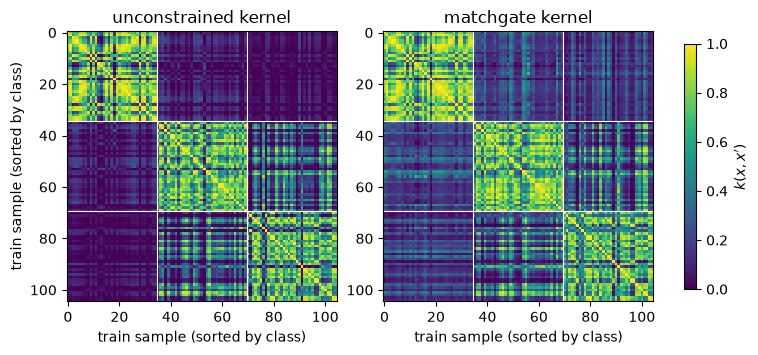

In [10]:
order = np.argsort(y_train, kind="stable")
class_edges = np.cumsum(np.bincount(y_train))[:-1] - 0.5
fig, axes = plt.subplots(1, 2, figsize=(7.5, 3.3), dpi=100, constrained_layout=True)
for ax, (name, gram) in zip(axes, gram_train.items()):
    image = ax.imshow(gram[np.ix_(order, order)], vmin=0, vmax=1, cmap="viridis", interpolation="nearest")
    for edge in class_edges:
        ax.axhline(edge, color="white", linewidth=0.8)
        ax.axvline(edge, color="white", linewidth=0.8)
    ax.set_title(f"{name} kernel")
    ax.set_xlabel("train sample (sorted by class)")
axes[0].set_ylabel("train sample (sorted by class)")
fig.colorbar(image, ax=axes, shrink=0.9, label="$k(x, x')$")
plt.show()

The confusion matrices on the test set show where each model makes its errors.

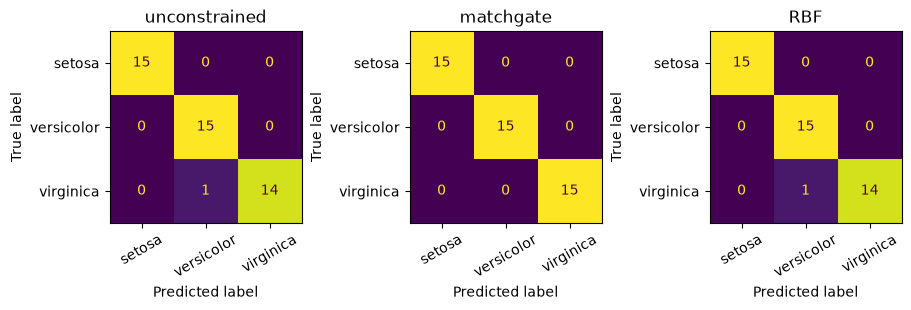

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.4), dpi=100, constrained_layout=True)
for ax, (name, y_pred) in zip(axes, predictions.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=dataset.target_names, ax=ax, colorbar=False)
    ax.tick_params(axis="x", labelrotation=30)
    ax.set_title(name)
plt.show()

## Cost scaling

`default.qubit` stores the $2^n$ amplitudes of the state, so its cost grows exponentially with the number of qubits
$n$. `mk.qubit` tracks a $2n \times 2n$ single-particle transition matrix and obtains the probability of
$|0\cdots0\rangle$ from a Pfaffian, so its cost grows polynomially. We time one kernel evaluation of the same
embedding on $n$ qubits with random inputs on both devices (best of 3 runs; `mk.qubit` uses one torch thread and
`default.qubit` uses NumPy).

default.qubit: n=4: 0.004 s, n=8: 0.006 s, n=12: 0.013 s, n=16: 0.047 s, n=18: 0.283 s, n=20: 1.110 s
     mk.qubit: n=4: 0.175 s, n=8: 0.362 s, n=12: 0.553 s, n=16: 0.740 s, n=20: 0.937 s, n=24: 1.137 s, n=32: 1.525 s


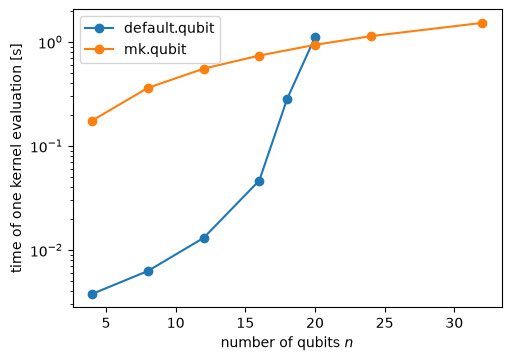

In [12]:
def time_kernel(device_name, n_qubits, rng, n_repeats=3):
    kernel = make_kernel(device_name, n_qubits)
    x1, x2 = rng.uniform(0, np.pi, size=(2, n_qubits))
    durations = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        kernel(x1, x2)
        durations.append(time.perf_counter() - start)
    return min(durations)


rng = np.random.default_rng(SEED)
qubit_counts = {"default.qubit": [4, 8, 12, 16, 18, 20], "mk.qubit": [4, 8, 12, 16, 20, 24, 32]}
timings = {name: [time_kernel(name, n, rng) for n in counts] for name, counts in qubit_counts.items()}
for name, counts in qubit_counts.items():
    print(f"{name:>13}: " + ", ".join(f"n={n}: {t:.3f} s" for n, t in zip(counts, timings[name])))

fig, ax = plt.subplots(figsize=(5, 3.5), dpi=100, constrained_layout=True)
for name, counts in qubit_counts.items():
    ax.plot(counts, timings[name], marker="o", label=name)
ax.set_yscale("log")
ax.set_xlabel("number of qubits $n$")
ax.set_ylabel("time of one kernel evaluation [s]")
ax.legend()
plt.show()

## Discussion

- **Both kernels are valid.** Both training Gram matrices have a unit diagonal, are symmetric, and have no negative
  eigenvalue beyond round-off (about $10^{-15}$). For the matchgate kernel, this is expected: it is the fidelity
  kernel of the matchgate circuit $V(x)$.
- **They are different kernels.** The translation of $U(x)$ is not exact, so `mk.qubit` does not reproduce the
  unconstrained kernel: it computes another one. The two differ by up to 0.63 (0.11 on average off the diagonal),
  and the matchgate kernel is larger on average (0.37 against 0.29). Both Gram matrices still show the three class
  blocks.
- **On Iris, the three models perform alike.** The test accuracies are 97.8% (unconstrained), 100% (matchgate) and
  97.8% (RBF). The two quantum models disagree on a single test sample out of 45, and their 5-fold CV accuracies differ
  by less than their standard deviations. The matchgate restriction costs no accuracy here, but no quantum advantage
  shows either: the classical RBF kernel does as well, so Iris is too easy to tell these kernels apart.
- **What the matchgate kernel gives up.** $V(x)|0000\rangle$ is a fermionic Gaussian (free-fermion) state, so the
  matchgate kernel only compares states of this family, which is much smaller than the set of states that general
  circuits prepare. On harder data, this restriction may cost accuracy; this notebook does not test it.
- **What it gains.** The cost of `default.qubit` grows exponentially with $n$ (a 32-qubit state vector alone takes
  $2^{32} \times 16$ bytes $= 64$ GiB), that of `mk.qubit` polynomially. For the 4 qubits of Iris, `default.qubit` is
  much faster, as the Gram-matrix timings show. In the stored scaling run, `default.qubit` becomes slower than
  `mk.qubit` around 20 qubits, while the time of `mk.qubit` keeps growing slowly up to 32 qubits.